In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import torch.cuda.amp as amp
import matplotlib.pyplot as plt
import numpy as np
import time


torch.backends.cudnn.benchmark = True
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 48.0MB/s]


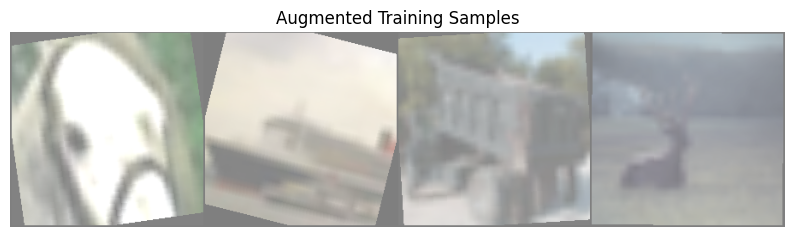

In [ ]:
# 2. DATA PREPARATION & VISUALIZATION

stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
batch_size = 128
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#  Visualizing Augmentation
def imshow(img, title=None):
    img = img / 2 + 0.5  #mathematical shortcut to reverse the normalization. It roughly scales the pixel values back to the visible [0, 1] range:
    npimg = img.numpy() # extracts the raw numbers from the PyTorch tensor and converts them into a standard NumPy array.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    if title:
        plt.title(title)
    plt.axis('off')

viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

vizset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=viz_transform)
vizloader = torch.utils.data.DataLoader(vizset, batch_size=4, shuffle=True)
dataiter = iter(vizloader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 5))
imshow(torchvision.utils.make_grid(images), title="Augmented Training Samples")
plt.show()


In [ ]:

# Experimental DataLoaders
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Baseline Loader
trainset_base = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_baseline)
trainloader_base = torch.utils.data.DataLoader(trainset_base, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Augmented Loader
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Shared Test Loader
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 channels -> 64 channels. 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 64 channels -> 128 channels. 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 128 channels -> 256 channels. 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 256 channels -> 512 channels. 4x4 -> 2x2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # After Block 4, our tensor is 512 channels of 2x2 images.
        # Math: 512 * 2 * 2 = 2048
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512 * 2 * 2, 512),
            nn.BatchNorm1d(512), # Added batch norm here for stability
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# 4. HIGH-PERFORMANCE TRAINING LOOP
def train_model(model, train_loader, test_loader, epochs=15, lr=0.11):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.91, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = amp.GradScaler()

    train_losses = []
    test_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad(set_to_none=True)

            # Automatic Mixed Precision
            with amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        # Evaluation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        epoch_acc = 100. * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(epoch_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

    print(f"Training finished in {time.time() - start_time:.0f}s")
    return train_losses, test_accs



In [ ]:
# 5. EXECUTION & A/B TESTING

epochs_to_run = 15

print("\n--- EXPERIMENT 1: Baseline (No Augmentation) ---")
model_base = CustomCNN().to(device)
loss_base, acc_base = train_model(model_base, trainloader_base, testloader, epochs=epochs_to_run)

print("\n--- EXPERIMENT 2: With Data Augmentation ---")
model_aug = CustomCNN().to(device)
loss_aug, acc_aug = train_model(model_aug, trainloader_aug, testloader, epochs=epochs_to_run)


--- EXPERIMENT 1: Baseline (No Augmentation) ---


/tmp/ipython-input-947/3944342627.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipython-input-947/3944342627.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch [01/15] | Loss: 1.8924 | Test Acc: 46.47%
Epoch [02/15] | Loss: 1.1762 | Test Acc: 66.39%
Epoch [03/15] | Loss: 0.8508 | Test Acc: 72.19%
Epoch [04/15] | Loss: 0.6818 | Test Acc: 73.32%
Epoch [05/15] | Loss: 0.5712 | Test Acc: 75.54%
Epoch [06/15] | Loss: 0.4921 | Test Acc: 76.13%
Epoch [07/15] | Loss: 0.4151 | Test Acc: 75.10%
Epoch [08/15] | Loss: 0.3471 | Test Acc: 81.63%
Epoch [09/15] | Loss: 0.2773 | Test Acc: 79.94%
Epoch [10/15] | Loss: 0.1913 | Test Acc: 83.78%
Epoch [11/15] | Loss: 0.1149 | Test Acc: 83.25%
Epoch [12/15] | Loss: 0.0513 | Test Acc: 86.82%
Epoch [13/15] | Loss: 0.0183 | Test Acc: 87.55%
Epoch [14/15] | Loss: 0.0085 | Test Acc: 87.88%
Epoch [15/15] | Loss: 0.0069 | Test Acc: 87.92%
Training finished in 268s

--- EXPERIMENT 2: With Data Augmentation ---
Epoch [01/15] | Loss: 2.0071 | Test Acc: 47.82%
Epoch [02/15] | Loss: 1.3221 | Test Acc: 49.57%
Epoch [03/15] | Loss: 1.0340 | Test Acc: 65.30%
Epoch [04/15] | Loss: 0.8369 | Test Acc: 72.40%
Epoch [05/15] | 

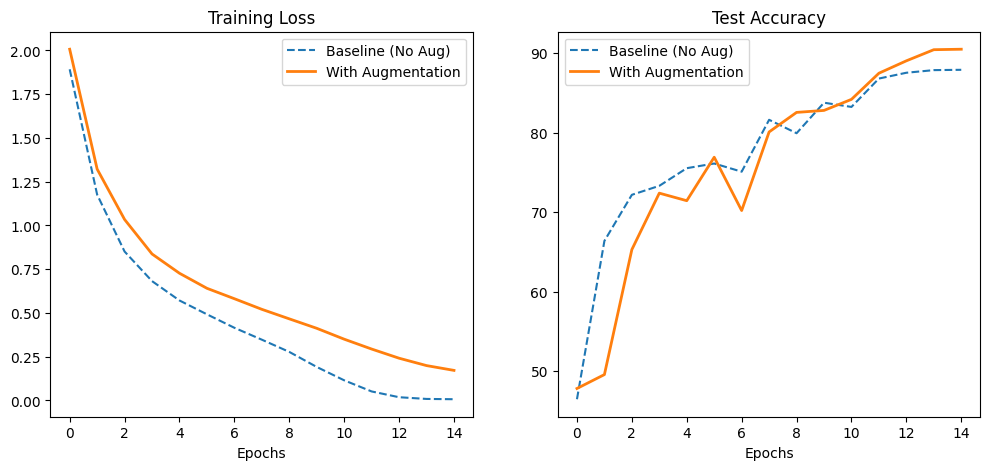

In [ ]:
# 6. PLOTTING THE RESULTS


plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(loss_aug, label='With Augmentation', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(acc_aug, label='With Augmentation', linewidth=2)
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.show()